In [1]:
from a3 import A3, lca, get_lcia_method_names, plot_temporal_scores
from datapackage import Package  # or however you load it

dp = Package("datapackage.json")
a3 = A3(dp, interpolate_annual=True)

In [2]:
methods = ['IPCC 2021 - climate change - global warming potential (GWP100)',]
results = lca(
    a3=a3,
    methods=methods,
    start_year=2050,
    start_act_idx=2,
    amount=1.0,
    max_depth=5,
    min_amount=1e-18,
)

Years in f_by_year: [2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026, 2027, 2028, 2029, 2030, 2031, 2032, 2033, 2034, 2035, 2036, 2037, 2038, 2039, 2040, 2041, 2042, 2043, 2044, 2045, 2046, 2047, 2048, 2049, 2050, 2051, 2052, 2053, 2054, 2055, 2056, 2057, 2058, 2059, 2060, 2061, 2062, 2063, 2064, 2065, 2066]
Nonzero activities in year 2050: [0 3]


NameError: name 'elec_idx' is not defined

In [ ]:
fig = plot_temporal_scores(
    results_by_year=results,
    stacked=False,
    a3=a3,
    title="BEV life-cycle impacts over time",
    method_label="kg CO₂-eq",
    cumulative=False
)
fig.show()


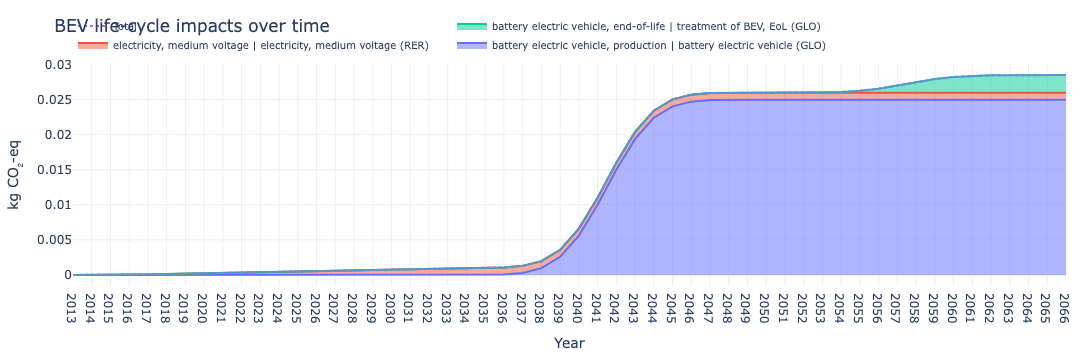

In [5]:
fig = plot_temporal_scores(
    results_by_year=results,
    a3=a3,
    title="BEV life-cycle impacts over time",
    method_label="kg CO₂-eq",
    cumulative=True
)
fig.show()

In [4]:
from a3.lca import build_datapackage_for_year_from_a3
from a3.lcia import get_lcia_methods, fill_characterization_factors_matrices
import numpy as np

year = 2049
methods_in_use = methods  # same list you used in temporal_lcia_from_a3

# Rebuild datapackage & indices for this year
dp, tech_idx, bio_idx, uncertain_params = build_datapackage_for_year_from_a3(
    a3=a3,
    year=year,
    remove_uncertainty=True,
)

# Rebuild LCA for this year (just once)
frontier = a3.temporal_traversal(
    start_year=2050,        # or your actual start year
    start_act_idx=1,        # same as before
    amount=1.0,
    max_depth=2,
    min_amount=1e-12,
)
f_by_year = a3.frontier_to_demand_vectors(frontier)
f = f_by_year[year]
nonzero = np.where(f != 0)[0]
fu = {int(i): float(f[i]) for i in nonzero}

import bw2calc as bc
lca = bc.LCA(demand=fu, data_objs=[dp])
lca.lci()

inventory = lca.inventory  # 1D array of biosphere flows

print("Inventory min/max:", inventory.min(), inventory.max())

# Build the mapping for LCIA
biosphere_matrix_dict = lca.dicts.biosphere  # {flow_id: row index}

biosphere_dict_simple = {
    (name, comp, subcomp): idx
    for (name, comp, subcomp, unit), idx in bio_idx.items()
}

lcia_data = get_lcia_methods(methods=methods_in_use)

# Build CF matrix
C = fill_characterization_factors_matrices(
    methods=methods_in_use,
    biosphere_matrix_dict=biosphere_matrix_dict,
    biosphere_dict=biosphere_dict_simple,
    debug=False,
)

print("CF matrix shape:", C.shape, "nnz:", C.nnz)
print("CF min/max:", C.data.min() if C.nnz else None, C.data.max() if C.nnz else None)

# Recompute scores explicitly
scores = C.dot(inventory)
print("Scores:", scores)


Inventory min/max: -1.6000001323845936 0.0
CF matrix shape: (1, 3) nnz: 1
CF min/max: 1.0 1.0
Scores: <Compressed Sparse Row sparse matrix of dtype 'float64'
	with 1 stored elements and shape (1, 9)>
  Coords	Values
  (0, 6)	-1.6000001323845936


In [4]:
from a3.lca import build_datapackage_for_year_from_a3
from a3.lcia import get_lcia_methods

year = 2049  # or any year that appears in results

dp, tech_idx, bio_idx, uncertain_params = build_datapackage_for_year_from_a3(
    a3=a3,
    year=year,
    remove_uncertainty=True,
)

lca = results[year]["lca"]
biosphere_matrix_dict = lca.dicts.biosphere  # {flow_id: row index}

# Build the mapping expected by fill_characterization_factors_matrices
biosphere_dict_simple = {
    (name, comp, subcomp): idx
    for (name, comp, subcomp, unit), idx in bio_idx.items()
}

print("Sample biosphere flows from DB:")
for k in list(biosphere_dict_simple.keys())[:10]:
    print("  DB  :", k)

# Use the same 'methods' list you passed to temporal_lcia_from_a3
lcia_data = get_lcia_methods(methods=methods)

print("\nSample LCIA flows from first method:")
m0 = methods[0]
for k in list(lcia_data[m0].keys())[:10]:
    print("  LCIA:", k)

intersection = set(lcia_data[m0].keys()) & set(biosphere_dict_simple.keys())
print("\nNumber of matching flows:", len(intersection))
print("Some matches:", list(intersection)[:10])


Sample biosphere flows from DB:
  DB  : ('Water', 'water', 'groundwater')
  DB  : ('Water', 'water', 'unspecified')
  DB  : ('Carbon dioxide, fossil', 'air', 'unspecified')

Sample LCIA flows from first method:
  LCIA: ('1,1,1,2-Tetrafluoroethane', 'air', 'low population density, long-term')
  LCIA: ('1,1,1,2-Tetrafluoroethane', 'air', 'non-urban air or from high stacks')
  LCIA: ('1,1,1,2-Tetrafluoroethane', 'air', 'unspecified')
  LCIA: ('1,1,1,2-Tetrafluoroethane', 'air', 'urban air close to ground')
  LCIA: ('1,1,1-Trichloroethane', 'air', 'low population density, long-term')
  LCIA: ('1,1,1-Trichloroethane', 'air', 'non-urban air or from high stacks')
  LCIA: ('1,1,1-Trichloroethane', 'air', 'unspecified')
  LCIA: ('1,1,1-Trichloroethane', 'air', 'urban air close to ground')
  LCIA: ('1,1,1-Trifluoroethane', 'air', 'low population density, long-term')
  LCIA: ('1,1,1-Trifluoroethane', 'air', 'non-urban air or from high stacks')

Number of matching flows: 1
Some matches: [('Carbon 

In [5]:
print("Sample bio_idx entries:")
for k, v in list(bio_idx.items())[:10]:
    print("  key:", k, "value:", v)


Sample bio_idx entries:
  key: ('Water', 'water', 'groundwater', 'cubic meter') value: 0
  key: ('Water', 'water', 'unspecified', 'cubic meter') value: 1
  key: ('Carbon dioxide, fossil', 'air', 'low population density', 'kilogram') value: 2


In [10]:
result = a3.expand_temporal_exchanges(year=2050, act_idx=1, amount=1.0)
result

{2005: {6: 2.400000113993883e-05},
 2006: {6: 9.600000455975531e-06},
 2007: {6: 1.1200000531971454e-05},
 2008: {6: 1.2800000607967377e-05},
 2009: {6: 1.4400000683963299e-05},
 2010: {6: 1.600000075995922e-05},
 2011: {6: 1.7600000835955143e-05},
 2012: {6: 1.9200000911951063e-05},
 2013: {6: 2.0800000987946986e-05},
 2014: {6: 2.240000106394291e-05},
 2015: {6: 2.400000113993883e-05},
 2016: {6: 2.5600001215934755e-05},
 2017: {6: 2.7200001291930674e-05},
 2018: {6: 2.8800001367926597e-05},
 2019: {6: 3.040000144392252e-05},
 2020: {6: 3.200000151991844e-05},
 2021: {6: 3.360000159591436e-05},
 2022: {6: 3.5200001671910286e-05},
 2023: {6: 3.680000174790621e-05},
 2024: {6: 3.8400001823902125e-05},
 2025: {6: 4.0000001899898055e-05},
 2026: {6: 3.8400001823902125e-05},
 2027: {6: 3.680000174790621e-05},
 2028: {6: 3.5200001671910286e-05},
 2029: {6: 3.360000159591436e-05},
 2030: {6: 3.200000151991844e-05},
 2031: {6: 3.040000144392252e-05},
 2032: {6: 2.8800001367926597e-05},
 2033

In [11]:
frontier = a3.temporal_traversal(
    start_year=2050,
    start_act_idx=1,
    amount=1.0,
    max_depth=2,      # say 2 layers for now
    min_amount=1e-12,
)

len(frontier), list(frontier.items())[:10]


(45,
 [((2005, 6), 2.400000113993883e-05),
  ((2006, 6), 9.600000455975531e-06),
  ((2007, 6), 1.1200000531971454e-05),
  ((2008, 6), 1.2800000607967377e-05),
  ((2009, 6), 1.4400000683963299e-05),
  ((2010, 6), 1.600000075995922e-05),
  ((2011, 6), 1.7600000835955143e-05),
  ((2012, 6), 1.9200000911951063e-05),
  ((2013, 6), 2.0800000987946986e-05),
  ((2014, 6), 2.240000106394291e-05)])

In [2]:
dp = Package("datapackage.json")

In [3]:
from a3 import A3

In [4]:
a3 = A3(dp)

In [5]:
a3.temporal_distributions

[{'classification_system': 'CPC',
  'classification_code': '17110',
  'distribution_type': 'triangular',
  'loc': 30.0,
  'scale': None,
  'shape': None,
  'min': 5.0,
  'max': 50.0}]

In [4]:
a3.A.dtype

NameError: name 'a3' is not defined

In [6]:
a3.B.dtype

dtype('float32')

In [7]:
a3.scenario_index

{'2005': 0,
 '2006': 1,
 '2007': 2,
 '2008': 3,
 '2009': 4,
 '2010': 5,
 '2011': 6,
 '2012': 7,
 '2013': 8,
 '2014': 9,
 '2015': 10,
 '2016': 11,
 '2017': 12,
 '2018': 13,
 '2019': 14,
 '2020': 15,
 '2021': 16,
 '2022': 17,
 '2023': 18,
 '2024': 19,
 '2025': 20,
 '2026': 21,
 '2027': 22,
 '2028': 23,
 '2029': 24,
 '2030': 25,
 '2031': 26,
 '2032': 27,
 '2033': 28,
 '2034': 29,
 '2035': 30,
 '2036': 31,
 '2037': 32,
 '2038': 33,
 '2039': 34,
 '2040': 35,
 '2041': 36,
 '2042': 37,
 '2043': 38,
 '2044': 39,
 '2045': 40,
 '2046': 41,
 '2047': 42,
 '2048': 43,
 '2049': 44,
 '2050': 45,
 '2051': 46,
 '2052': 47,
 '2053': 48,
 '2054': 49,
 '2055': 50,
 '2056': 51,
 '2057': 52,
 '2058': 53,
 '2059': 54,
 '2060': 55,
 '2061': 56,
 '2062': 57,
 '2063': 58,
 '2064': 59,
 '2065': 60,
 '2066': 61,
 '2067': 62,
 '2068': 63,
 '2069': 64,
 '2070': 65,
 '2071': 66,
 '2072': 67,
 '2073': 68,
 '2074': 69,
 '2075': 70,
 '2076': 71,
 '2077': 72,
 '2078': 73,
 '2079': 74,
 '2080': 75,
 '2081': 76,
 '2082': 

In [8]:
a3.scenario_labels

['2005',
 '2006',
 '2007',
 '2008',
 '2009',
 '2010',
 '2011',
 '2012',
 '2013',
 '2014',
 '2015',
 '2016',
 '2017',
 '2018',
 '2019',
 '2020',
 '2021',
 '2022',
 '2023',
 '2024',
 '2025',
 '2026',
 '2027',
 '2028',
 '2029',
 '2030',
 '2031',
 '2032',
 '2033',
 '2034',
 '2035',
 '2036',
 '2037',
 '2038',
 '2039',
 '2040',
 '2041',
 '2042',
 '2043',
 '2044',
 '2045',
 '2046',
 '2047',
 '2048',
 '2049',
 '2050',
 '2051',
 '2052',
 '2053',
 '2054',
 '2055',
 '2056',
 '2057',
 '2058',
 '2059',
 '2060',
 '2061',
 '2062',
 '2063',
 '2064',
 '2065',
 '2066',
 '2067',
 '2068',
 '2069',
 '2070',
 '2071',
 '2072',
 '2073',
 '2074',
 '2075',
 '2076',
 '2077',
 '2078',
 '2079',
 '2080',
 '2081',
 '2082',
 '2083',
 '2084',
 '2085',
 '2086',
 '2087',
 '2088',
 '2089',
 '2090',
 '2091',
 '2092',
 '2093',
 '2094',
 '2095',
 '2096',
 '2097',
 '2098',
 '2099',
 '2100']

In [9]:
a3.activity_indices

{'2005': {0: {'name': 'Li+ extraction, brine, CL',
   'reference product': 'Li+, aq',
   'unit': 'kilogram',
   'location': 'CL'},
  1: {'name': 'Electricity, hydropower, CL',
   'reference product': 'electricity, hydropower',
   'unit': 'kilowatt hour',
   'location': 'CL'},
  2: {'name': 'Li2CO3 production, CN',
   'reference product': 'lithium carbonate',
   'unit': 'kilogram',
   'location': 'CN'},
  3: {'name': 'Electricity, hydropower, CN',
   'reference product': 'electricity, hydropower',
   'unit': 'kilowatt hour',
   'location': 'CN'},
  4: {'name': 'CAM production, DE',
   'reference product': 'cathode active material',
   'unit': 'kilogram',
   'location': 'DE'},
  5: {'name': 'Electricity, hydropower, DE',
   'reference product': 'electricity, hydropower',
   'unit': 'kilowatt hour',
   'location': 'DE'},
  6: {'name': 'Hydropower plant construction, CL',
   'reference product': 'hydropower plant',
   'unit': 'unit',
   'location': 'CL'},
  7: {'name': 'Hydropower plant co

In [11]:
a3.biosphere_index

{}